In [1]:
# 1. Importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Wczytanie danych z CSV
df = pd.read_csv('C:/ML-danych-pogodowych/data/pogodynka_zbilansowana.csv')

# 3. Kategoryzacja natężenia opadu
def opad_kategoria(x):
    if x == 0:
        return 0  # brak
    elif x < 1:
        return 1  # słaby
    elif x < 3:
        return 2  # średni
    else:
        return 3  # silny

df['Opad_kat'] = df['Opad'].apply(opad_kategoria)

# 4. Przygotowanie cech i etykiet
X = df.drop(columns=['Opad', 'Opad_kat', 'iddepeszy', 'Kategoria'])
y = df['Opad_kat']

print("Kształt danych wejściowych:", X.shape)
print("Kształt etykiet:", y.shape)

Kształt danych wejściowych: (49883, 34)
Kształt etykiet: (49883,)


In [2]:
# 5. Standaryzacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# 7. Uczenie modelu KNN (domyślnie k=5)
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [3]:
# 8. Predykcja
y_pred = model_knn.predict(X_test)

# 9. Ewaluacja
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8224523889074508

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89     11122
           1       0.70      0.53      0.60      3680
           2       0.50      0.11      0.18       152
           3       1.00      0.09      0.17        11

    accuracy                           0.82     14965
   macro avg       0.76      0.42      0.46     14965
weighted avg       0.81      0.82      0.81     14965



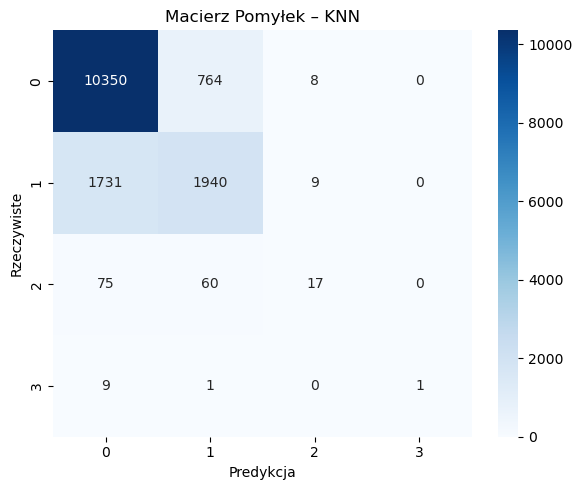

In [4]:
# 10. Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywiste')
plt.title('Macierz Pomyłek – KNN')
plt.tight_layout()
plt.show()

                         cecha   ważność
10                 ZjawiskaPop  0.031654
21                OtoczenieE_P  0.008600
32                     godzina  0.007918
20                OtoczenieS_P  0.007805
3         TemperaturaPowietrza  0.007350
25                OtoczenieE_O  0.007317
23                OtoczenieN_O  0.006976
4               DeficytPktRosy  0.006749
16                OtoczenieS_B  0.006722
31                     miesiac  0.006569
27                      WiatrN  0.006515
17                OtoczenieE_B  0.006194
30                      WiatrW  0.005947
1                  Widzialnosc  0.005900
22                OtoczenieW_P  0.005894
29                      WiatrE  0.005433
19                OtoczenieN_P  0.005352
24                OtoczenieS_O  0.005352
18                OtoczenieW_B  0.005199
28                      WiatrS  0.005139
2         WielkoscZachmurzenia  0.004477
8   WielkoscTendencjiCisnienia  0.004357
26                OtoczenieW_O  0.004330
5               

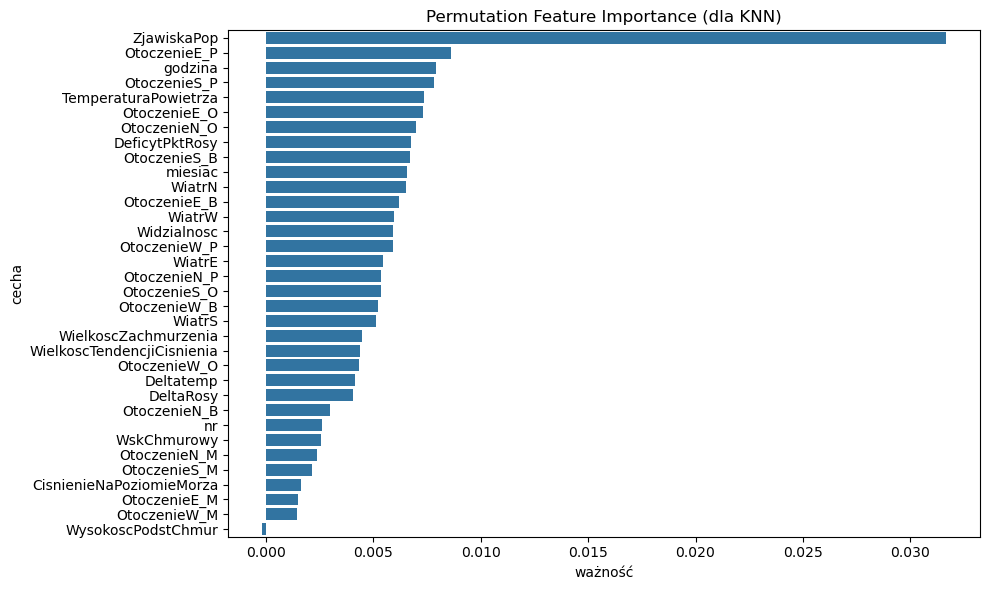

In [5]:
from sklearn.inspection import permutation_importance

# Obliczanie ważności cech przez permutacje
r = permutation_importance(model_knn, X_test, y_test, n_repeats=10, random_state=42)

# Tworzenie DataFrame z wynikami
importance_df = pd.DataFrame({
    'cecha': X.columns,
    'ważność': r.importances_mean
}).sort_values(by='ważność', ascending=False)

# Wyświetlenie tabeli
print(importance_df)

# Wykres
plt.figure(figsize=(10, 6))
sns.barplot(x='ważność', y='cecha', data=importance_df)
plt.title('Permutation Feature Importance (dla KNN)')
plt.tight_layout()
plt.show()
